In [2]:
import pandas as pd

from email_outreach.experiment_utils.metric_loader import load_experiment_metrics
from email_outreach.ml.shallow_autoencoder.abstract_contextual_model import AbstractContextualModel
from email_outreach.ml.shallow_autoencoder.alpha_scheduler import ConstantAlphaScheduler, LinearAlphaScheduler, \
    GeometricAlphaScheduler, AdaptiveAlphaScheduler, AlphaSchedulerArgs, AlphaSchedulerFactory
from email_outreach.utils.constants import ROOT_FOLDER
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [3]:
NUM_BATCHES = 24
sent_by_T = 0.15
sent_after_T = 0.1


batch_sizes = [sent_by_T / NUM_BATCHES] * NUM_BATCHES + [sent_after_T]
batch_nums = list(range(0, NUM_BATCHES + 1))

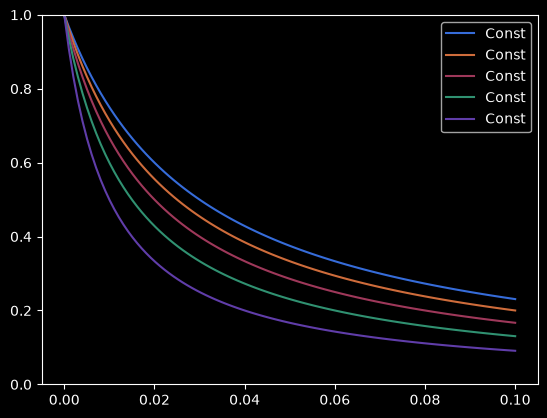

In [6]:
open_frac: float = np.linspace(start=0, stop=0.1, num=100)

# plt.plot(open_frac, [AdaptiveAlphaScheduler(0.035)(AlphaSchedulerArgs(0, frac)) for frac in open_frac], label="Const")`

plt.plot(open_frac, [AdaptiveAlphaScheduler(0.03)(AlphaSchedulerArgs(0, frac)) for frac in open_frac], label="Const")

plt.plot(open_frac, [AdaptiveAlphaScheduler(0.025)(AlphaSchedulerArgs(0, frac)) for frac in open_frac], label="Const")

plt.plot(open_frac, [AdaptiveAlphaScheduler(0.02)(AlphaSchedulerArgs(0, frac)) for frac in open_frac], label="Const")

plt.plot(open_frac, [AdaptiveAlphaScheduler(0.015)(AlphaSchedulerArgs(0, frac)) for frac in open_frac], label="Const")

plt.plot(open_frac, [AdaptiveAlphaScheduler(0.01)(AlphaSchedulerArgs(0, frac)) for frac in open_frac], label="Const")

# plt.plot(open_frac, [AdaptiveAlphaScheduler(0.005)(AlphaSchedulerArgs(0, frac)) for frac in open_frac], label="Const")

plt.ylim(0, 1)
plt.legend()

In [5]:
lin_conf = {
        "d": 16,
        "epochs": 30,
        "lr": 0.01,
        "wd": 0.0001,
        "batch_size": 16,
        "G": 10000,
        "T": 2880,
        "sent_by_T": 0.15,
        "sent_after_T": 0.1,
        "num_splits": 24,
        "alpha_type": "linear",
        "alpha_params": {
            "left_bound": 0.4,
            "right_bound": 0.1
        }
}


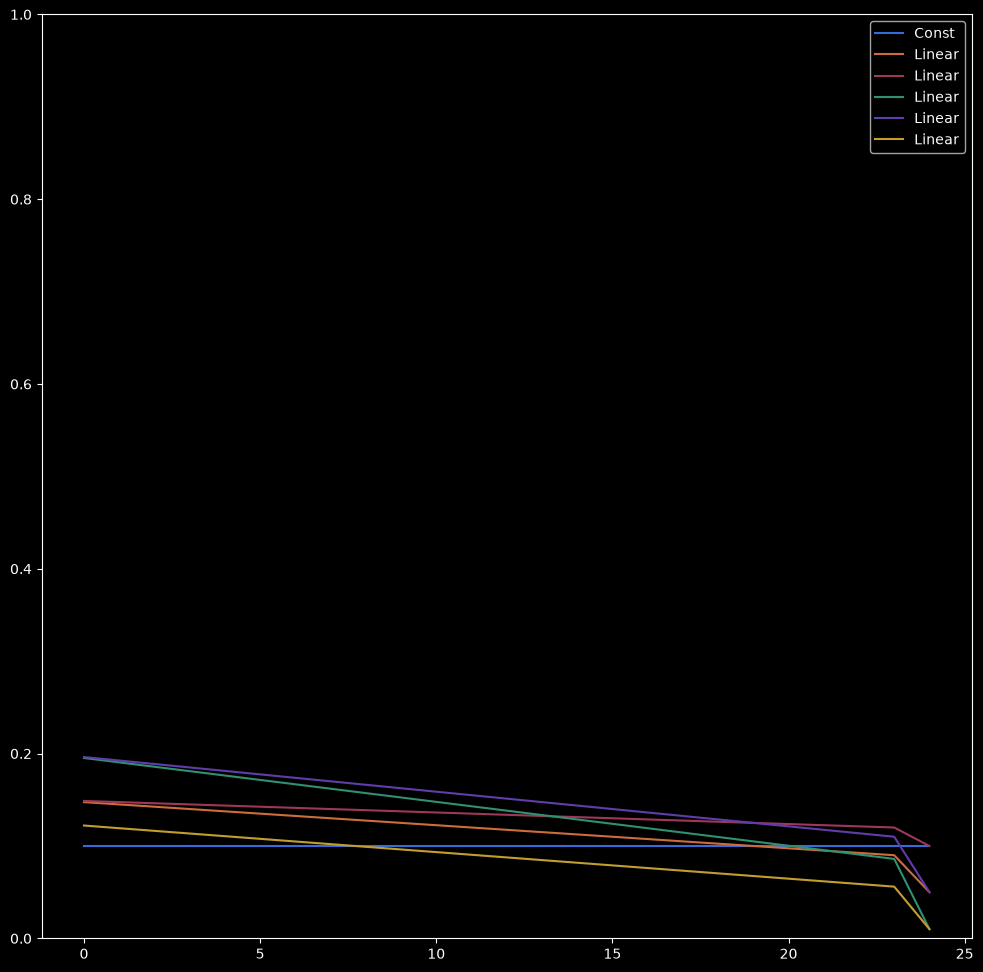

In [6]:
linear_alpha_scheduler = AlphaSchedulerFactory.from_config(lin_conf)


plt.figure(figsize=(12, 12))

plt.plot(batch_nums, [ConstantAlphaScheduler(0.1)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Const")

plt.plot(batch_nums, [LinearAlphaScheduler(0.15, 0.05, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Linear")

plt.plot(batch_nums, [LinearAlphaScheduler(0.15, 0.1, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Linear")

plt.plot(batch_nums, [LinearAlphaScheduler(0.2, 0.01, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Linear")

plt.plot(batch_nums, [LinearAlphaScheduler(0.2, 0.05, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Linear")


plt.plot(batch_nums, [LinearAlphaScheduler(0.125, 0.01, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Linear")


# plt.plot(batch_nums, [LinearAlphaScheduler(0.3, 0.15, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Linear")


plt.ylim(0, 1)
plt.legend()

In [7]:
geom_conf = {
        "d": 16,
        "epochs": 30,
        "lr": 0.01,
        "wd": 0.0001,
        "batch_size": 16,
        "G": 10000,
        "T": 2880,
        "sent_by_T": 0.15,
        "sent_after_T": 0.1,
        "num_splits": 24,
        "alpha_type": "geometric",
        "alpha_params": {
            "left_bound": 0.5,
            "right_bound": 0.1
        }
}


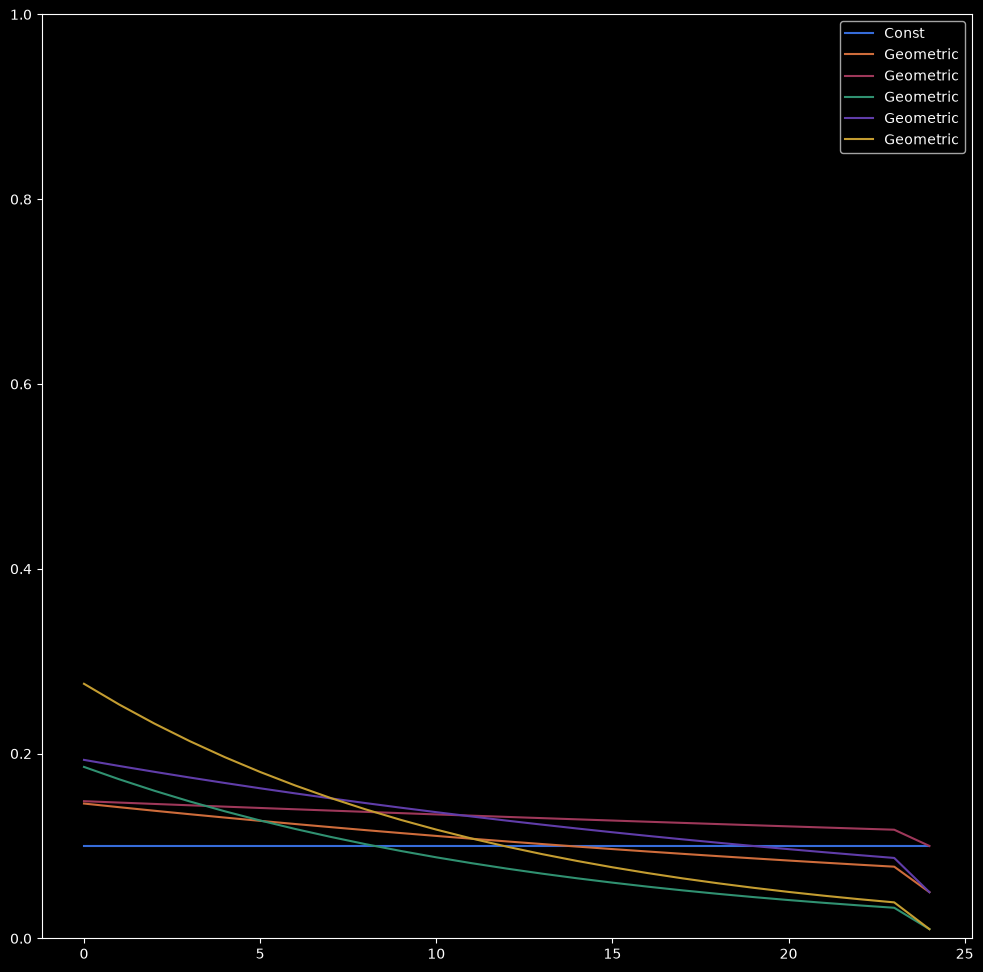

In [8]:
geometric_alpha_scheduler = AlphaSchedulerFactory.from_config(geom_conf)



plt.figure(figsize=(12, 12))

plt.plot(batch_nums, [ConstantAlphaScheduler(0.1)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Const")

plt.plot(batch_nums, [GeometricAlphaScheduler(0.15, 0.05, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Geometric")

plt.plot(batch_nums, [GeometricAlphaScheduler(0.15, 0.1, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Geometric")

plt.plot(batch_nums, [GeometricAlphaScheduler(0.2, 0.01, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Geometric")

plt.plot(batch_nums, [GeometricAlphaScheduler(0.2, 0.05, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Geometric")


plt.plot(batch_nums, [GeometricAlphaScheduler(0.3, 0.01, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Geometric")

# plt.plot(batch_nums, [GeometricAlphaScheduler(0.3, 0.2, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Geometric")

# plt.plot(batch_nums, [GeometricAlphaScheduler(0.3, 0.15, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Geometric")


# plt.plot(batch_nums, [GeometricAlphaScheduler(0.25, 0.15, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Geometric")


# plt.plot(batch_nums, [LinearAlphaScheduler(0.3, 0.15, batch_sizes)(AlphaSchedulerArgs(batch_num, 0)) for batch_num in batch_nums], label="Linear")


plt.ylim(0, 1)
plt.legend()

In [9]:
def get_precisions_recalls(path: Path, quantiles=1 - np.linspace(start=0, stop=1, num=100)):
    experiments: list[list] = load_experiment_metrics(path)
    recalls: list[float] = []
    precisions: list[float] = []
    for experiment in experiments:
        recall, precision = AbstractContextualModel.calculate_recall_precision_at_quantiles(experiment,
                                                                                            quantiles=quantiles)[1:3]

        recalls.append(recall)
        precisions.append(precision)

    return recalls, precisions

In [10]:
const_alpha_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "baseline"
geometric_alpha_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "geometric_alpha"
lin_alpha_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "linear_alpha"

adaptive_alpha_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "adaptive_alpha"
# sigmoid_alpha_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "sigmoid_alpha"
# weak_alpha_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "weak_const"

In [11]:
const_recalls, const_precisions = get_precisions_recalls(const_alpha_path)
lin_recalls, lin_precisions = get_precisions_recalls(lin_alpha_path)
geometric_recalls, geometric_precisions = get_precisions_recalls(geometric_alpha_path)
adaptive_recalls, adaptive_precisions = get_precisions_recalls(adaptive_alpha_path)
# weak_recalls, weak_precisions = get_precisions_recalls(weak_alpha_path)

In [12]:
print(f"Const recall: {np.array(const_recalls).mean(axis=0)}")
print(f"Lin recall: {np.array(lin_recalls).mean(axis=0)}")
print(f"Geometric recall: {np.array(geometric_recalls).mean(axis=0)}")
print(f"Adaptive recall: {np.array(adaptive_recalls).mean(axis=0)}")
# print(f"Weak recall: {np.array(weak_recalls).mean(axis=0)}")

Const recall: [3.12075052e-05 3.09546501e-02 1.27430414e-01 2.24620259e-01
 3.10711362e-01 3.84651217e-01 4.48944917e-01 5.03436012e-01
 5.53600796e-01 6.06030703e-01 6.57547169e-01 7.03190888e-01
 7.41921737e-01 7.74804656e-01 8.00482675e-01 8.21350049e-01
 8.37900337e-01 8.51987032e-01 8.64264165e-01 8.75441498e-01
 8.85209685e-01 8.93955572e-01 9.02118299e-01 9.09823641e-01
 9.16743273e-01 9.23415361e-01 9.28908504e-01 9.33978552e-01
 9.38015179e-01 9.41959181e-01 9.45461534e-01 9.48885132e-01
 9.51784757e-01 9.54099198e-01 9.56051271e-01 9.58026808e-01
 9.60086029e-01 9.61904085e-01 9.63673826e-01 9.65015782e-01
 9.66433119e-01 9.67556939e-01 9.68657939e-01 9.69598676e-01
 9.70360089e-01 9.71071515e-01 9.71852127e-01 9.72641866e-01
 9.73290874e-01 9.74257364e-01 9.74934795e-01 9.75679848e-01
 9.76271123e-01 9.76934231e-01 9.77525815e-01 9.78155392e-01
 9.78827136e-01 9.79450759e-01 9.79971293e-01 9.80425002e-01
 9.80963221e-01 9.81384816e-01 9.81975128e-01 9.82452377e-01
 9.8304377

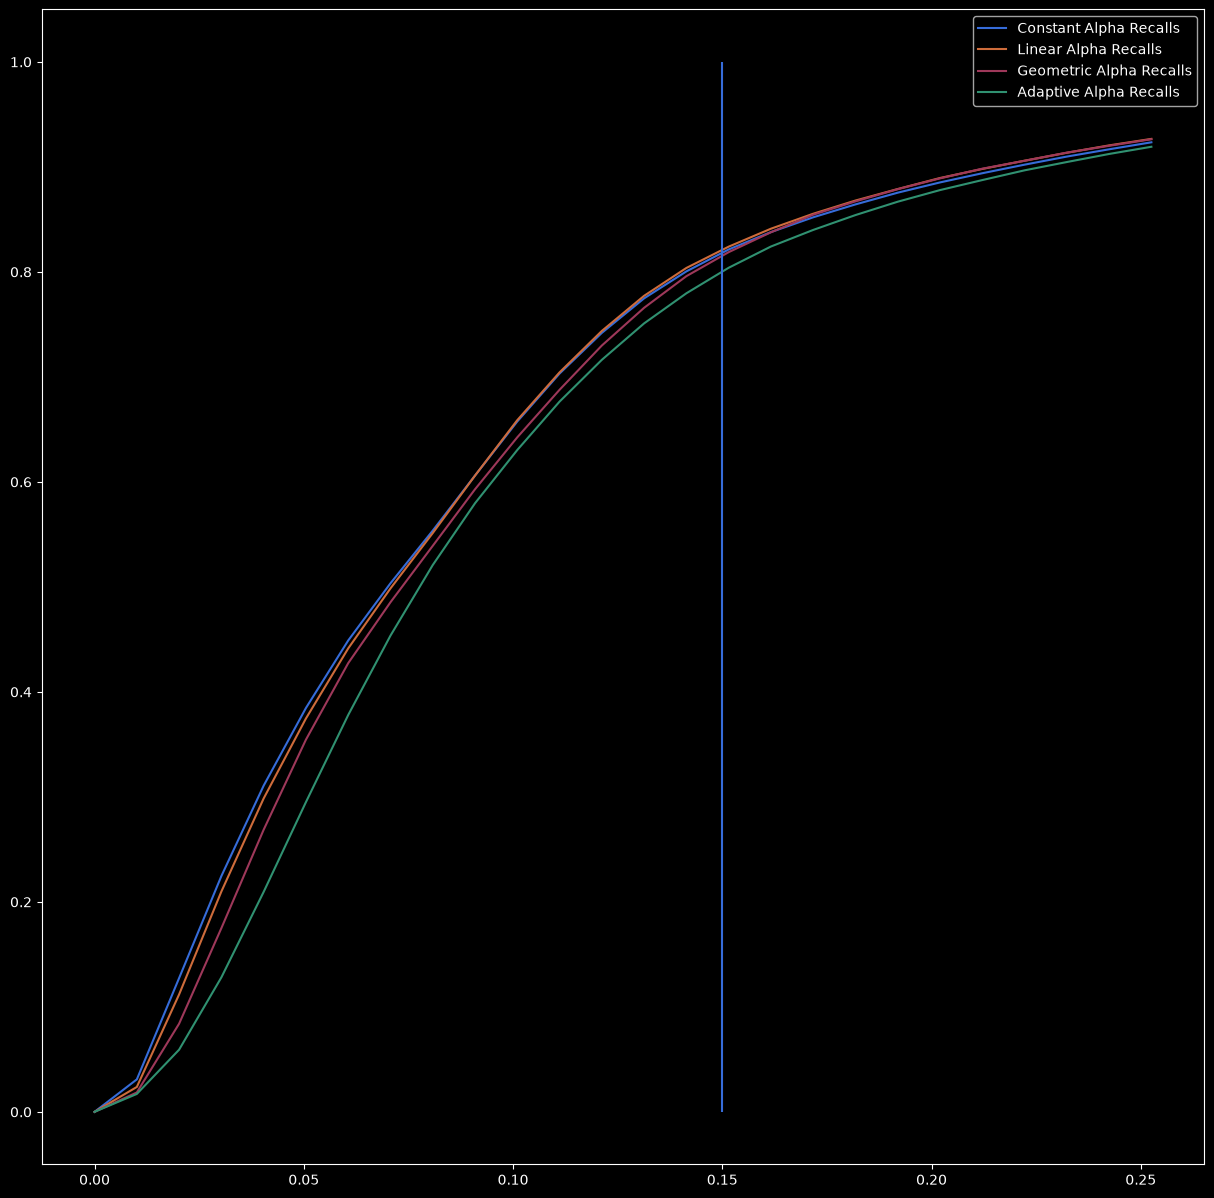

In [13]:
plt.figure(figsize=(15,15))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(const_recalls).mean(axis=0)[:26],
         label="Constant Alpha Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(lin_recalls).mean(axis=0)[:26],
         label="Linear Alpha Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(geometric_recalls).mean(axis=0)[:26],
         label="Geometric Alpha Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(adaptive_recalls).mean(axis=0)[:26],
         label="Adaptive Alpha Recalls")

plt.vlines(x=0.15, ymin=0, ymax=1)
plt.legend()
plt.show()

In [14]:
np.mean(get_precisions_recalls(const_alpha_path, quantiles=[0.75])[0])

np.float64(0.9218911655247531)

In [15]:
np.mean(get_precisions_recalls(geometric_alpha_path, quantiles=[0.75])[0])

np.float64(0.9248155264727591)

In [16]:
np.mean(get_precisions_recalls(lin_alpha_path, quantiles=[0.75])[0])

np.float64(0.9250486835835878)

In [17]:
np.mean(get_precisions_recalls(adaptive_alpha_path, quantiles=[0.75])[0])

np.float64(0.9176025214872985)

In [18]:
geom_corr = np.concat([np.array(geometric_recalls)[:9], np.array(geometric_recalls)[10:]])

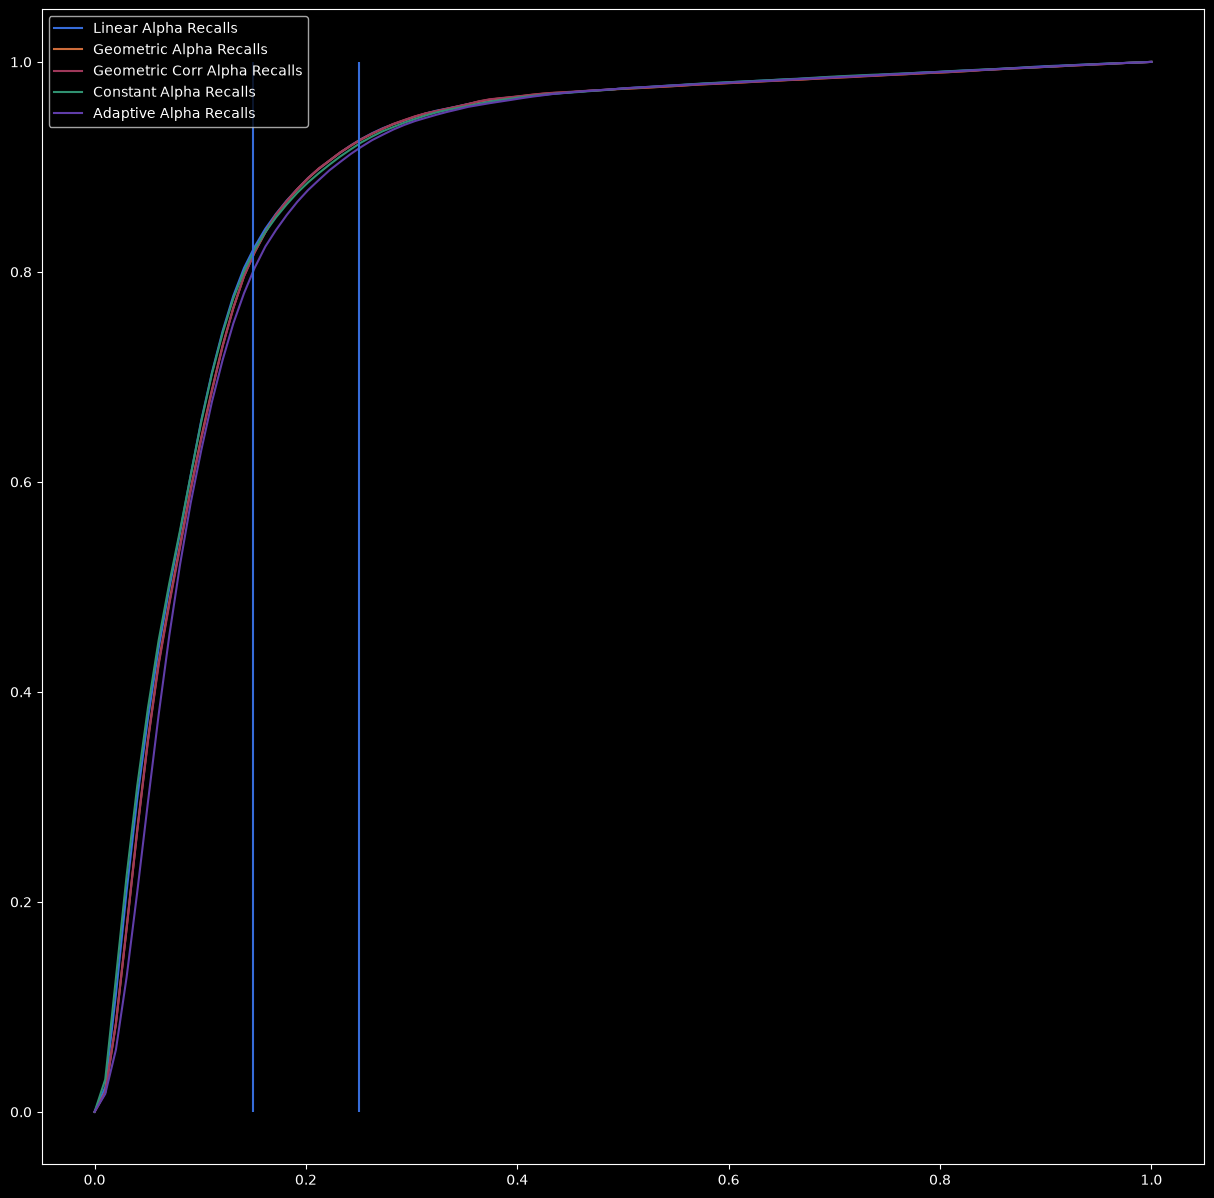

In [19]:
plt.figure(figsize=(15, 15))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(lin_recalls).mean(axis=0), label="Linear Alpha Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100), np.array(geometric_recalls).mean(axis=0),
         label="Geometric Alpha Recalls")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(geom_corr).mean(axis=0),
         label="Geometric Corr Alpha Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100), np.array(const_recalls).mean(axis=0),
         label="Constant Alpha Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100), np.array(adaptive_recalls).mean(axis=0),
         label="Adaptive Alpha Recalls")

plt.vlines(x=0.15, ymin=0, ymax=1)
plt.vlines(x=0.25, ymin=0, ymax=1)
# plt.hlines(y=0.923, xmin=0, xmax=1)
plt.legend()
plt.show()

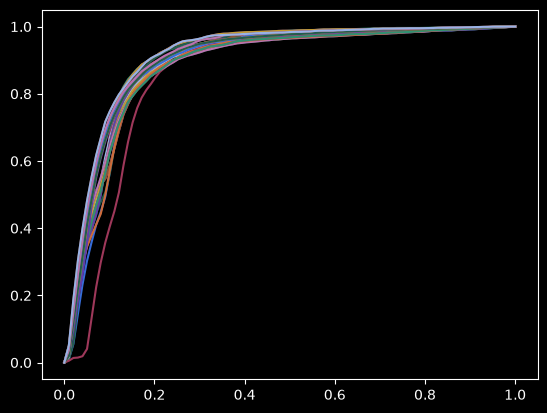

In [20]:
for i in range(30):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(const_recalls)[i],
         label="Adaptive Alpha Recalls")

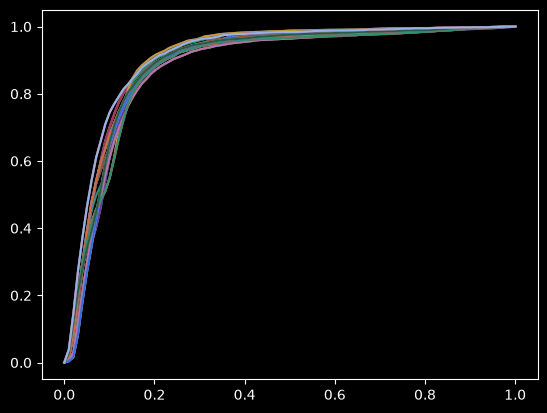

In [21]:
for i in range(30):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(geometric_recalls)[i],
         label="Adaptive Alpha Recalls")

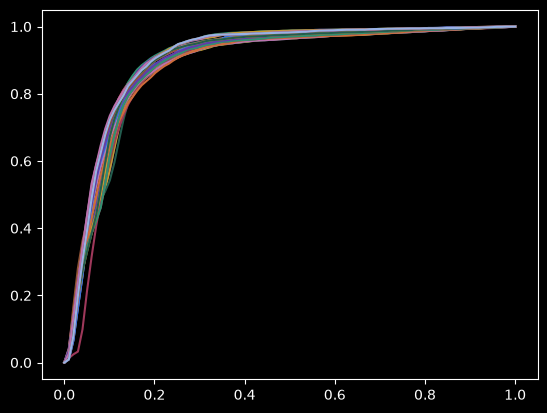

In [22]:
for i in range(30):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(lin_recalls)[i],
         label="Adaptive Alpha Recalls")

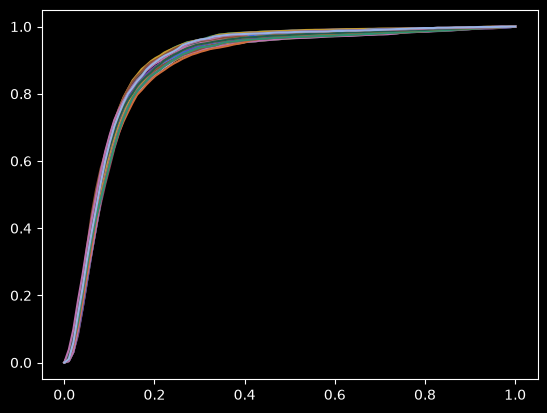

In [23]:
for i in range(len(adaptive_recalls)):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(adaptive_recalls)[i],
         label="Adaptive Alpha Recalls")

ValueError: x and y must have same first dimension, but have shapes (25,) and (100,)

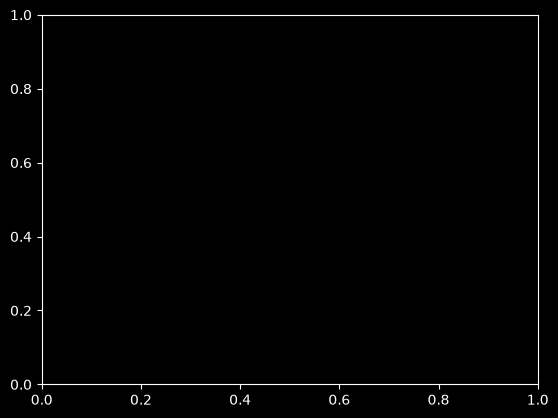

In [24]:
for i in range(len(adaptive_recalls)):
    plt.plot(np.linspace(start=0, stop=0.25, num=25), np.array(adaptive_recalls)[i],
         label="Adaptive Alpha Recalls")

In [ ]:
plt.figure(figsize=(15, 15))

plt.plot(np.linspace(start=0, stop=0.25, num=25), np.array(lin_precisions).mean(axis=0), label="Linear Alpha Precisions")
plt.plot(np.linspace(start=0, stop=0.25, num=25), np.array(geometric_precisions).mean(axis=0),
         label="Geometric Alpha Precisions")
plt.plot(np.linspace(start=0, stop=0.25, num=25), np.array(const_precisions).mean(axis=0),
         label="Constant Alpha Precisions")

plt.plot(np.linspace(start=0, stop=0.25, num=25), np.array(adaptive_precisions).mean(axis=0),
         label="Adaptive Alpha Precisions")

plt.vlines(x=0.15, ymin=0, ymax=1)
plt.legend()
plt.show()

$$
s_j(t) = \pi_j(t) u_j(t)
$$

$$
\pi_j(t) = \alpha(t)\phi_j + (1-\alpha(t))f_j(t)
$$

$$
u_j(t) = \beta(t)p_j + (1-\beta(t))1
$$

$$
s_j(t) = \biggl( \alpha(t)\phi_j + [1-\alpha(t)]f_j(t)\biggr) \biggl(\beta(t)p_j + [1-\beta(t)]1\biggr)
$$

Special case:

$$
\beta(t) = 1
$$

$$
s_j()
$$

$f_j(t) = \bar x_{n+1}^{T}\Sigma_{:j}$